In [9]:
from RL_algorithms.PPO2 import PPO, ActorCritic, train as ppo_train
from environments.EMS_env import MicrogridEnv, NormalisedMG, EvalMG
import matplotlib.pyplot as plt
import numpy as np
import torch

In [ ]:
loc = ".logs/ems/"
set_of_weights = np.array([[1., 4.0, 1.],
                           [1., 3.0, 1.],
                           [1., 2.0, 1.],
                           [1., 1., 1.],
                            [1., 1., 2.],
                           [1., 1., 3.],
                           [1., 1., 4.], 
                           [1., 2., 2.], 
                           [1., 4., 4.]])

for i, weights in enumerate(set_of_weights[:4]):
    ### ppo training
    ppo_env = NormalisedMG(MicrogridEnv(weights=weights))  
    path = f"{loc}weights_{i}/ppo2/"
    ppo_train(ppo_env, 
                max_training_timesteps=1_600_000,
                update_freq=144*16,
                eval_freq=144*256,
                log_path="./trying",
                eval_env= EvalMG(NormalisedMG(MicrogridEnv(weights=weights, mode="eval"))),
                n_epochs=5)

/home/lyapunov/anaconda3/lib/python3.12/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/lyapunov/anaconda3/lib/python3.12/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/home/lyapunov/anaconda3/lib/python3.12/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/lyapunov/anaconda3/lib/python3.12/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


training environment name : MGEnv


KeyboardInterrupt: 

In [3]:
import pandas as pd 
df = pd.read_csv("trying/evaluations.csv")

In [7]:
df

,episode,timestep,reward,std
0,0,432,-1118.294275,241.542802
1,1,864,-1085.105331,302.503685
2,2,1296,-1134.054031,213.471869
3,3,1728,-1078.240799,229.862970
4,4,2160,-1044.711578,204.293881
...,...,...,...,...
338,338,146448,15.236989,175.114045
339,339,146880,74.430284,114.259018
340,340,147312,-11.830917,169.360718
341,341,147744,73.383480,82.489360


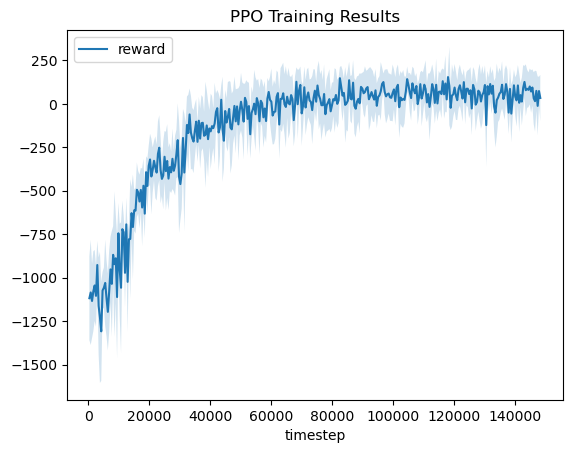

In [12]:
df.plot(x="timestep", y=["reward"], title="PPO Training Results")
plt.fill_between(df["timestep"], df["reward"] - df["std"], df["reward"] + df["std"], alpha=0.2)


In [5]:
data = np.load("logs/ems/weights_0/sac/evaluations.npz")
data["timesteps"]

array([  36864,   73728,  110592,  147456,  184320,  221184,  258048,
        294912,  331776,  368640,  405504,  442368,  479232,  516096,
        552960,  589824,  626688,  663552,  700416,  737280,  774144,
        811008,  847872,  884736,  921600,  958464,  995328, 1032192,
       1069056, 1105920, 1142784, 1179648, 1216512, 1253376, 1290240,
       1327104, 1363968, 1400832, 1437696, 1474560, 1511424, 1548288,
       1585152])

In [8]:
1_600_000/43, 36864/144

(37209.3023255814, 256.0)